In [1]:
%load_ext autoreload
%autoreload 2

from folde.util import load_checkpointed_model_eval, convert_compaign_result_collection_to_df, DMS_SHORTNAMES
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
MULTIMUTANTS = [
    ("SPG1_STRSG_Olson_2014", 0.0),
    ("GRB2_HUMAN_Faure_2021", 0.0),
    ("PABP_YEAST_Melamed_2013", 1.0),
]

multimutant_dms_ids = [v[0] for v in MULTIMUTANTS]

# Load data for left panels (graphical abstract dataset)
multi_results = load_checkpointed_model_eval(
    'notebooks/jacob/model_evals/',
    '251003-multimutant-benchmark',
    []
)
multi_mutant_df, multi_round_metrics_df = convert_compaign_result_collection_to_df(multi_results)
multi_mutant_df = multi_mutant_df[multi_mutant_df.dms_id.isin(multimutant_dms_ids)]
multi_round_metrics_df = multi_round_metrics_df[multi_round_metrics_df.dms_id.isin(multimutant_dms_ids)]

# Load data for left panels (graphical abstract dataset)
singles_results = load_checkpointed_model_eval(
    'notebooks/jacob/model_evals/',
    '251003-test-benchmark',
    []
)
singles_mutant_df, singles_round_metrics_df = convert_compaign_result_collection_to_df(singles_results)

round_metrics_df = singles_round_metrics_df


Loading results for DMSs: {'SPG1_STRSG_Olson_2014', 'PABP_YEAST_Melamed_2013', 'GRB2_HUMAN_Faure_2021'}
Loading results for DMSs: {'CAS9_STRP1_Spencer_2017_positive', 'MTHR_HUMAN_Weile_2021', 'HMDH_HUMAN_Jiang_2019', 'LGK_LIPST_Klesmith_2015', 'MLAC_ECOLI_MacRae_2023', 'A4GRB6_PSEAI_Chen_2020', 'S22A1_HUMAN_Yee_2023_activity', 'AMIE_PSEAE_Wrenbeck_2017', 'PTEN_HUMAN_Mighell_2018', 'PPARG_HUMAN_Majithia_2016', 'KKA2_KLEPN_Melnikov_2014', 'MSH2_HUMAN_Jia_2020', 'RNC_ECOLI_Weeks_2023', 'SC6A4_HUMAN_Young_2021', 'KCNJ2_MOUSE_Coyote-Maestas_2022_function', 'MET_HUMAN_Estevam_2023', 'PAI1_HUMAN_Huttinger_2021'}


In [2]:
round_metrics_df.config_name.value_counts()

config_name
FolDE-no-zeroShot                           1020
FolDE-clS6                                  1020
FolDE-base                                  1020
FolDE-no-constantliar                       1020
FolDE-no-BTLoss                             1020
FolDE-no-MLP                                1020
RandomToRandomForest-base                   1020
FolDE-clS1                                  1020
FolDE-no-ensemble                           1020
Random                                      1020
OnlyNaturalness                             1020
RandomToRandomForest-300m-embeddings        1020
FolDE-clS3                                  1020
FolDE-no-naturalnessTraining                1020
FolDE-no-naturalnessTraining-or-ensemble    1020
Name: count, dtype: int64

Adding legend


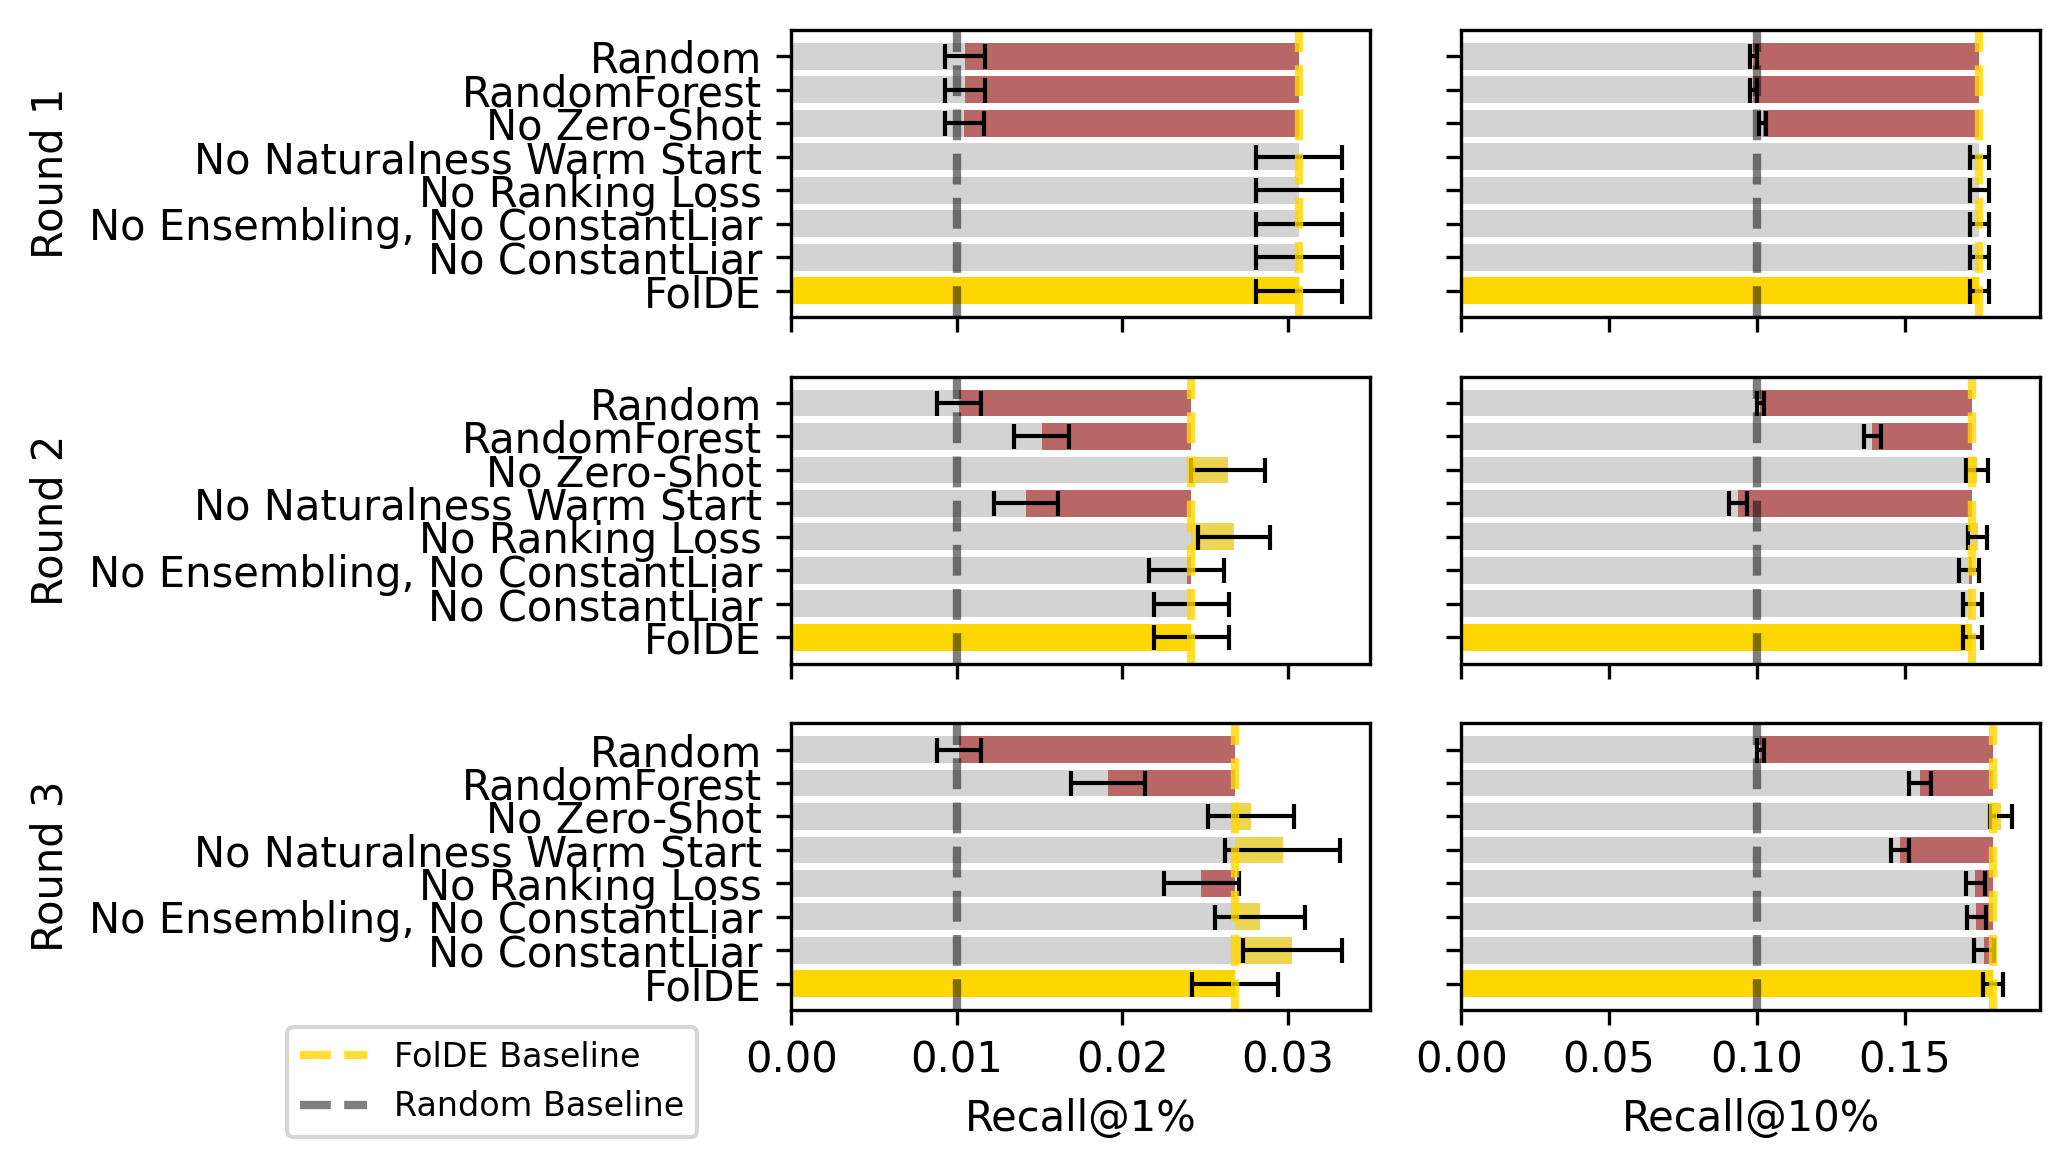

In [3]:
# METRIC = 'held_out_10pct_recall'

N_ROUNDS = 3


configs = [
    # ('FolDE-base', 'FolDE'),
    # ('FolDE-clS6-schedule', 'FolDE CL schedule'),
    ('FolDE-base', 'FolDE'),
    ('FolDE-no-constantliar', 'No ConstantLiar'),
    ('FolDE-no-ensemble', 'No Ensembling, No ConstantLiar'),
    ('FolDE-no-BTLoss', 'No Ranking Loss'),
    ('FolDE-no-naturalnessTraining', 'No Naturalness Warm Start'),
    ('FolDE-no-zeroShot', 'No Zero-Shot'),
    ('RandomToRandomForest-base', 'RandomForest'),
    ('Random', 'Random')
]


plot_df = round_metrics_df.copy()
plot_df['config_name'] = plot_df['config_name'].apply(lambda x: dict(configs).get(x, x))

# plt.figure(figsize=(3, 3), dpi=300)
fig, axs = plt.subplots(N_ROUNDS, 2, figsize=(7, 4), dpi=300, sharey=True, sharex='col')

for row_idx, row_axs in enumerate(axs):
    for ax, metric in zip(row_axs, ['held_out_1pct_recall', 'held_out_10pct_recall']):
        subplot_df = plot_df[(plot_df.round_num == row_idx + 1) & (plot_df.config_name.isin([c for _, c in configs]))]
        
        # Get FolDE baseline performance for this round and metric
        folde_performance = subplot_df[subplot_df.config_name == 'FolDE'][metric].mean()
        
        # Create grouped data by config for shading
        config_means = subplot_df.groupby('config_name')[metric].mean()
        
        # Plot bars for each config
        y_positions = range(len(configs))
        bar_heights = [config_means.get(config[1], 0) for config in configs]
        
        # Create bars
        # Calculate standard errors for each config
        config_sems = subplot_df.groupby('config_name')[metric].sem()
        bar_errors = [config_sems.get(config[1], 0) for config in configs]
        
        bars = ax.barh(y_positions, bar_heights,
                      xerr=bar_errors,
                      color=['gold' if config[1] == 'FolDE' else 'lightgrey' for config in configs],
                      error_kw=dict(ecolor='black', capsize=3, capthick=1, elinewidth=1))
        # Add shaded regions from FolDE performance down to each ablation
        for i, (_, config_name) in enumerate(configs):
            if config_name != 'FolDE':  # Skip FolDE itself
                ablation_performance = config_means.get(config_name, 0)
                # Shade the region between FolDE and this ablation
                ax.barh(i, folde_performance - ablation_performance,
                       left=ablation_performance,
                       color='gold' if ablation_performance > folde_performance else 'darkred',
                       alpha=0.6, height=0.8)
        # Set y-axis labels
        ax.set_yticks(y_positions)
        ax.set_yticklabels([config[1] for config in configs])
        
        # Add FolDE baseline line
        ax.axvline(x=folde_performance, color='gold', linewidth=2, alpha=0.8, linestyle='--', label='FolDE Baseline')

# Clean up legends
for row_idx, row_axs in enumerate(axs):
    for col_idx, ax in enumerate(row_axs):

        # Handle x-axis labels.
        if row_idx == N_ROUNDS - 1:
            if col_idx == 0:
                ax.set_xlabel('Recall@1%')
            else:
                ax.set_xlabel('Recall@10%')
        else:
            ax.set_xlabel('')

        # Handle y-axis labels.
        if col_idx == 0:
            ax.set_ylabel(f'Round {row_idx + 1}')
        else:
            ax.set_ylabel('')

        # Add random baseline
        if col_idx == 0:
            ax.axvline(x=0.01, color='black', linewidth=2, alpha=0.5, linestyle='--', label='Random Baseline')
        else:
            ax.axvline(x=0.1, color='black', linewidth=2, alpha=0.5, linestyle='--', label='Random Baseline')

        # Handle legend
        if col_idx == 0 and row_idx == N_ROUNDS - 1:
            print('Adding legend')
            ax.legend(
                # title='Workflow',
                loc='center left',
                bbox_to_anchor=(-0.9, -0.25),
                fontsize=8
            )

plt.tight_layout()

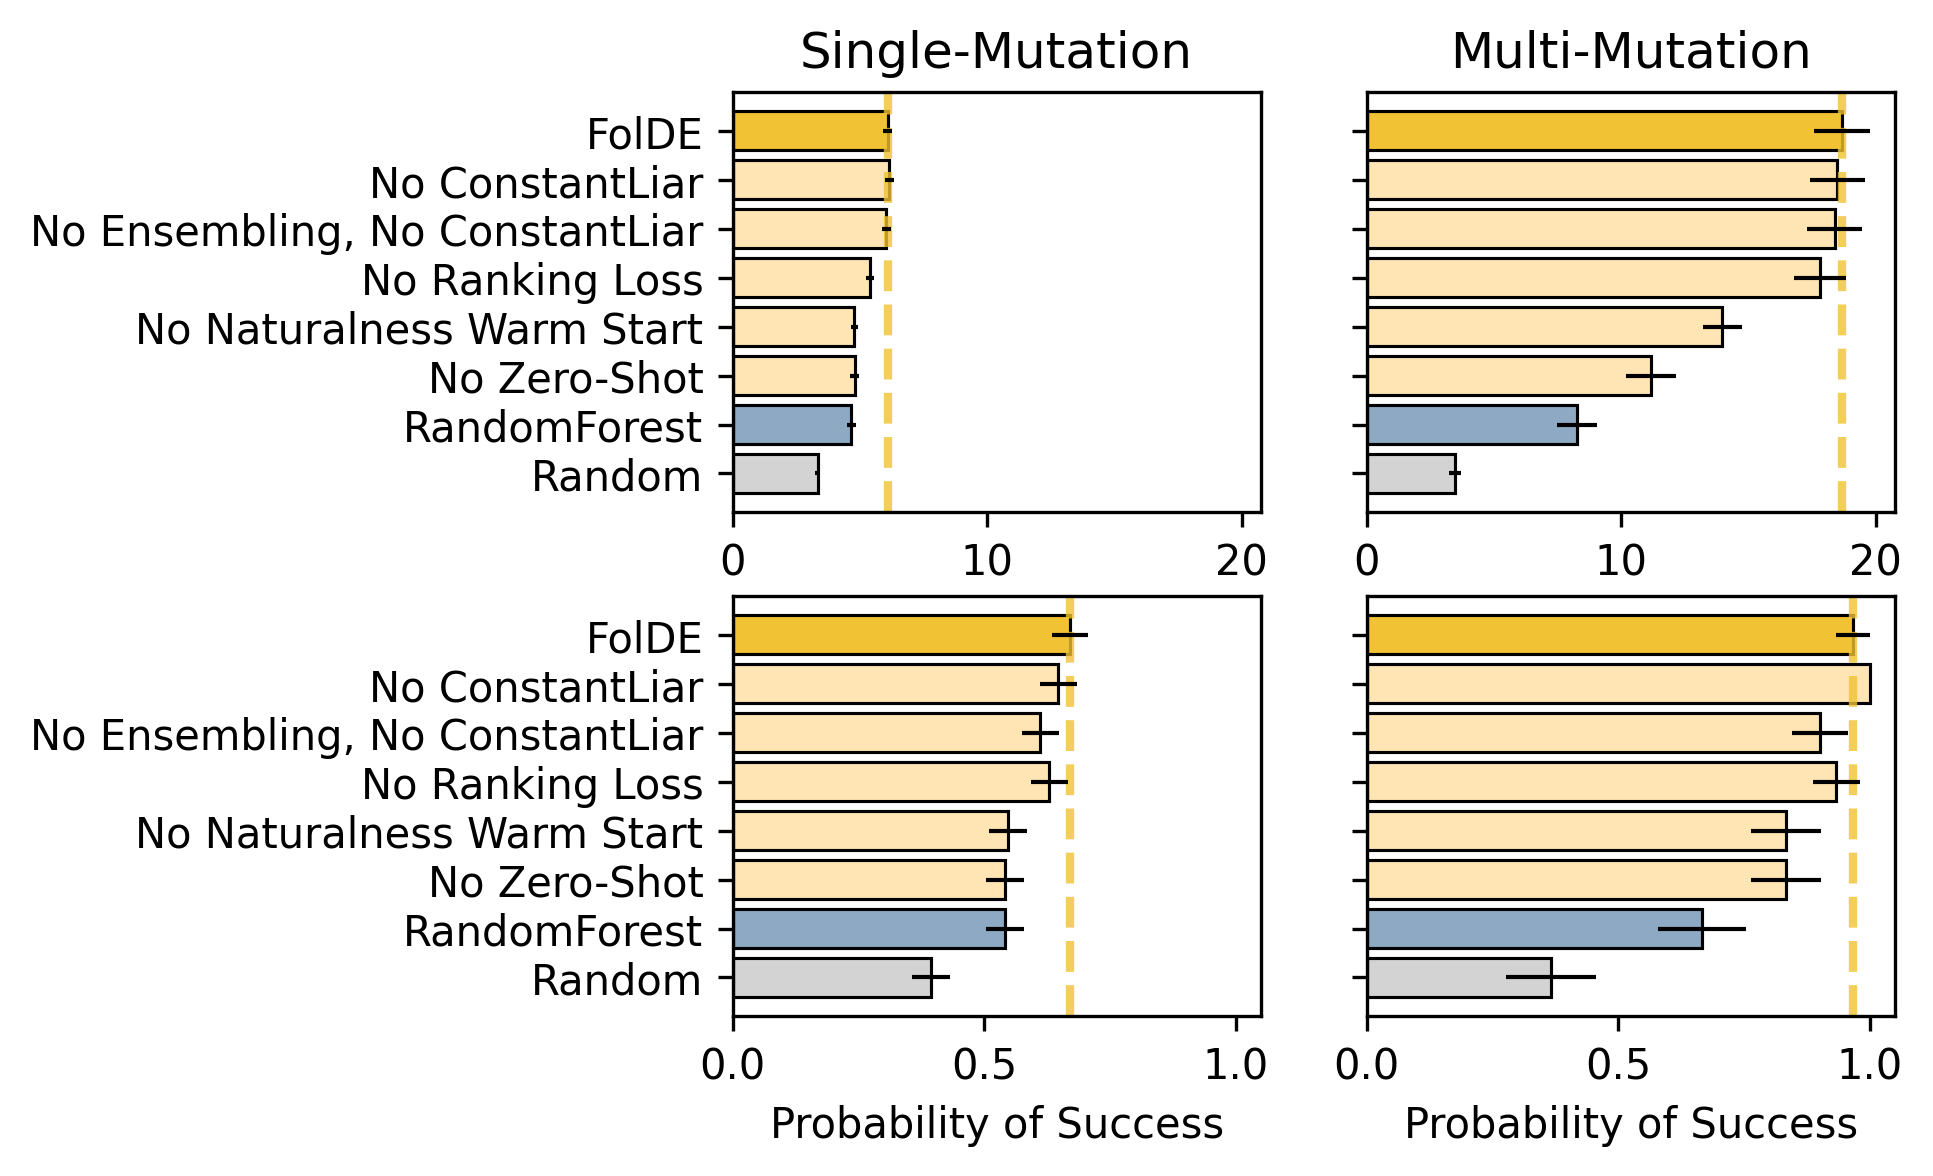

In [4]:
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns


N_ROUNDS = 3

configs = [
    # ('FolDE-base', 'FolDE'),
    # ('FolDE-clS6-schedule', 'FolDE CL schedule'),
    ('FolDE-base', 'FolDE'),
    ('FolDE-no-constantliar', 'No ConstantLiar'),
    ('FolDE-no-ensemble', 'No Ensembling, No ConstantLiar'),
    ('FolDE-no-BTLoss', 'No Ranking Loss'),
    ('FolDE-no-naturalnessTraining', 'No Naturalness Warm Start'),
    ('FolDE-no-zeroShot', 'No Zero-Shot'),
    ('RandomToRandomForest-base', 'RandomForest'),
    ('Random', 'Random')
]


def make_ablation_plot(specific_round_metrics_df, ax, metric):
    plot_df = specific_round_metrics_df.copy()
    plot_df['config_name'] = plot_df['config_name'].apply(lambda x: dict(configs).get(x, x))

    plot_df['batch_enrichment'] = (plot_df.held_out_batch_1pct / 0.01 + plot_df.held_out_batch_10pct / 0.1) / 2.0

    # plot_df['enrichment'] = plot_df.held_out_1pct_recall / 0.01 + plot_df.held_out_10pct_recall / 0.1
    if metric == 'has_found_top_1pct':
        subplot_df = plot_df[(plot_df.round_num == 3) & plot_df.config_name.isin([c for _, c in configs])]
    else:
        subplot_df = plot_df[(plot_df.round_num <= 3) & plot_df.config_name.isin([c for _, c in configs])]

    # Get FolDE baseline performance for this round and metric
    folde_performance = subplot_df[subplot_df.config_name == 'FolDE'][metric].mean()

    # Create grouped data by config for shading
    config_means = subplot_df.groupby('config_name')[metric].mean()

    # Plot bars for each config
    y_positions = [-i for i in range(len(configs))]
    bar_heights = [config_means.get(config[1], 0) for config in configs]

    # Create bars
    # Calculate standard errors for each config
    config_sems = subplot_df.groupby('config_name')[metric].sem()
    bar_errors = [config_sems.get(config[1], 0) for config in configs]

    ax.axvline(x=folde_performance, color='#F1C233', linewidth=2, alpha=0.8, linestyle='--', label='FolDE Baseline')
    bars = ax.barh(
        y_positions, bar_heights,
        edgecolor='black', linewidth=0.75,
        color=[{
            'FolDE': '#F1C233',
            'RandomForest': '#8DA9C4',
            'Random': 'lightgrey'
        }.get(config[1], '#FFE5B4') for config in configs],
        xerr=bar_errors, error_kw=dict(ecolor='black', capthick=1, elinewidth=1)
    )
    # Add shaded regions from FolDE performance down to each ablation
    # for i, (_, config_name) in enumerate(configs):
    #     if config_name != 'FolDE':  # Skip FolDE itself
    #         ablation_performance = config_means.get(config_name, 0)
    #         # Shade the region between FolDE and this ablation
    #         ax.barh(
    #             -i, folde_performance - ablation_performance,
    #             left=ablation_performance,
    #             alpha=0.6, height=0.8,
    #             color='gold' if ablation_performance > folde_performance else 'darkred',
    #         )
    # Set y-axis labels
    ax.set_yticks(y_positions)
    ax.set_yticklabels([config[1] for config in configs])

    # Add FolDE baseline line
    # ax.axvline(x=subplot_df[subplot_df.config_name == 'Random'][METRIC].mean(), color='grey', linewidth=2, alpha=0.8, linestyle='--', label='Random Baseline')

    if metric == 'batch_enrichment':
        ax.set_xlabel('3-Round Enrichment')
    elif metric == 'has_found_top_1pct':
        ax.set_xlabel('Probability of Success')
    elif metric == 'new_10pct_hits':
        ax.set_xlabel('Number of Mutants in Top 10%\n(Per Round of 16)')
    else:
        ax.set_xlabel(metric)

fig, ((ax_tl, ax_tr), (ax_bl, ax_br)) = plt.subplots(2, 2, figsize=(5, 4), dpi=300, sharey=True, sharex='row')


# METRIC = 'has_found_top_1pct'
# METRIC = 'new_10pct_hits'
make_ablation_plot(singles_round_metrics_df, ax_tl, 'cumulative_10pct_hits')
make_ablation_plot(multi_round_metrics_df, ax_tr, 'cumulative_10pct_hits')
make_ablation_plot(singles_round_metrics_df, ax_bl, 'has_found_top_1pct')
make_ablation_plot(multi_round_metrics_df, ax_br, 'has_found_top_1pct')
ax_tl.set_title('Single-Mutation')
ax_tr.set_title('Multi-Mutation')
# ax2.set_xticks([0, 2, 4, 6, 8])

fig.savefig('notebooks/jacob/paperplots/fig4_ablation_study.png', transparent=True, dpi=300, bbox_inches='tight')
# fig, ax = plt.subplots(1, 1, figsize=(3, 2), dpi=300)
# make_ablation_plot(multi_round_metrics_df, ax)
# ax.set_title('Multi-Round Baseline')

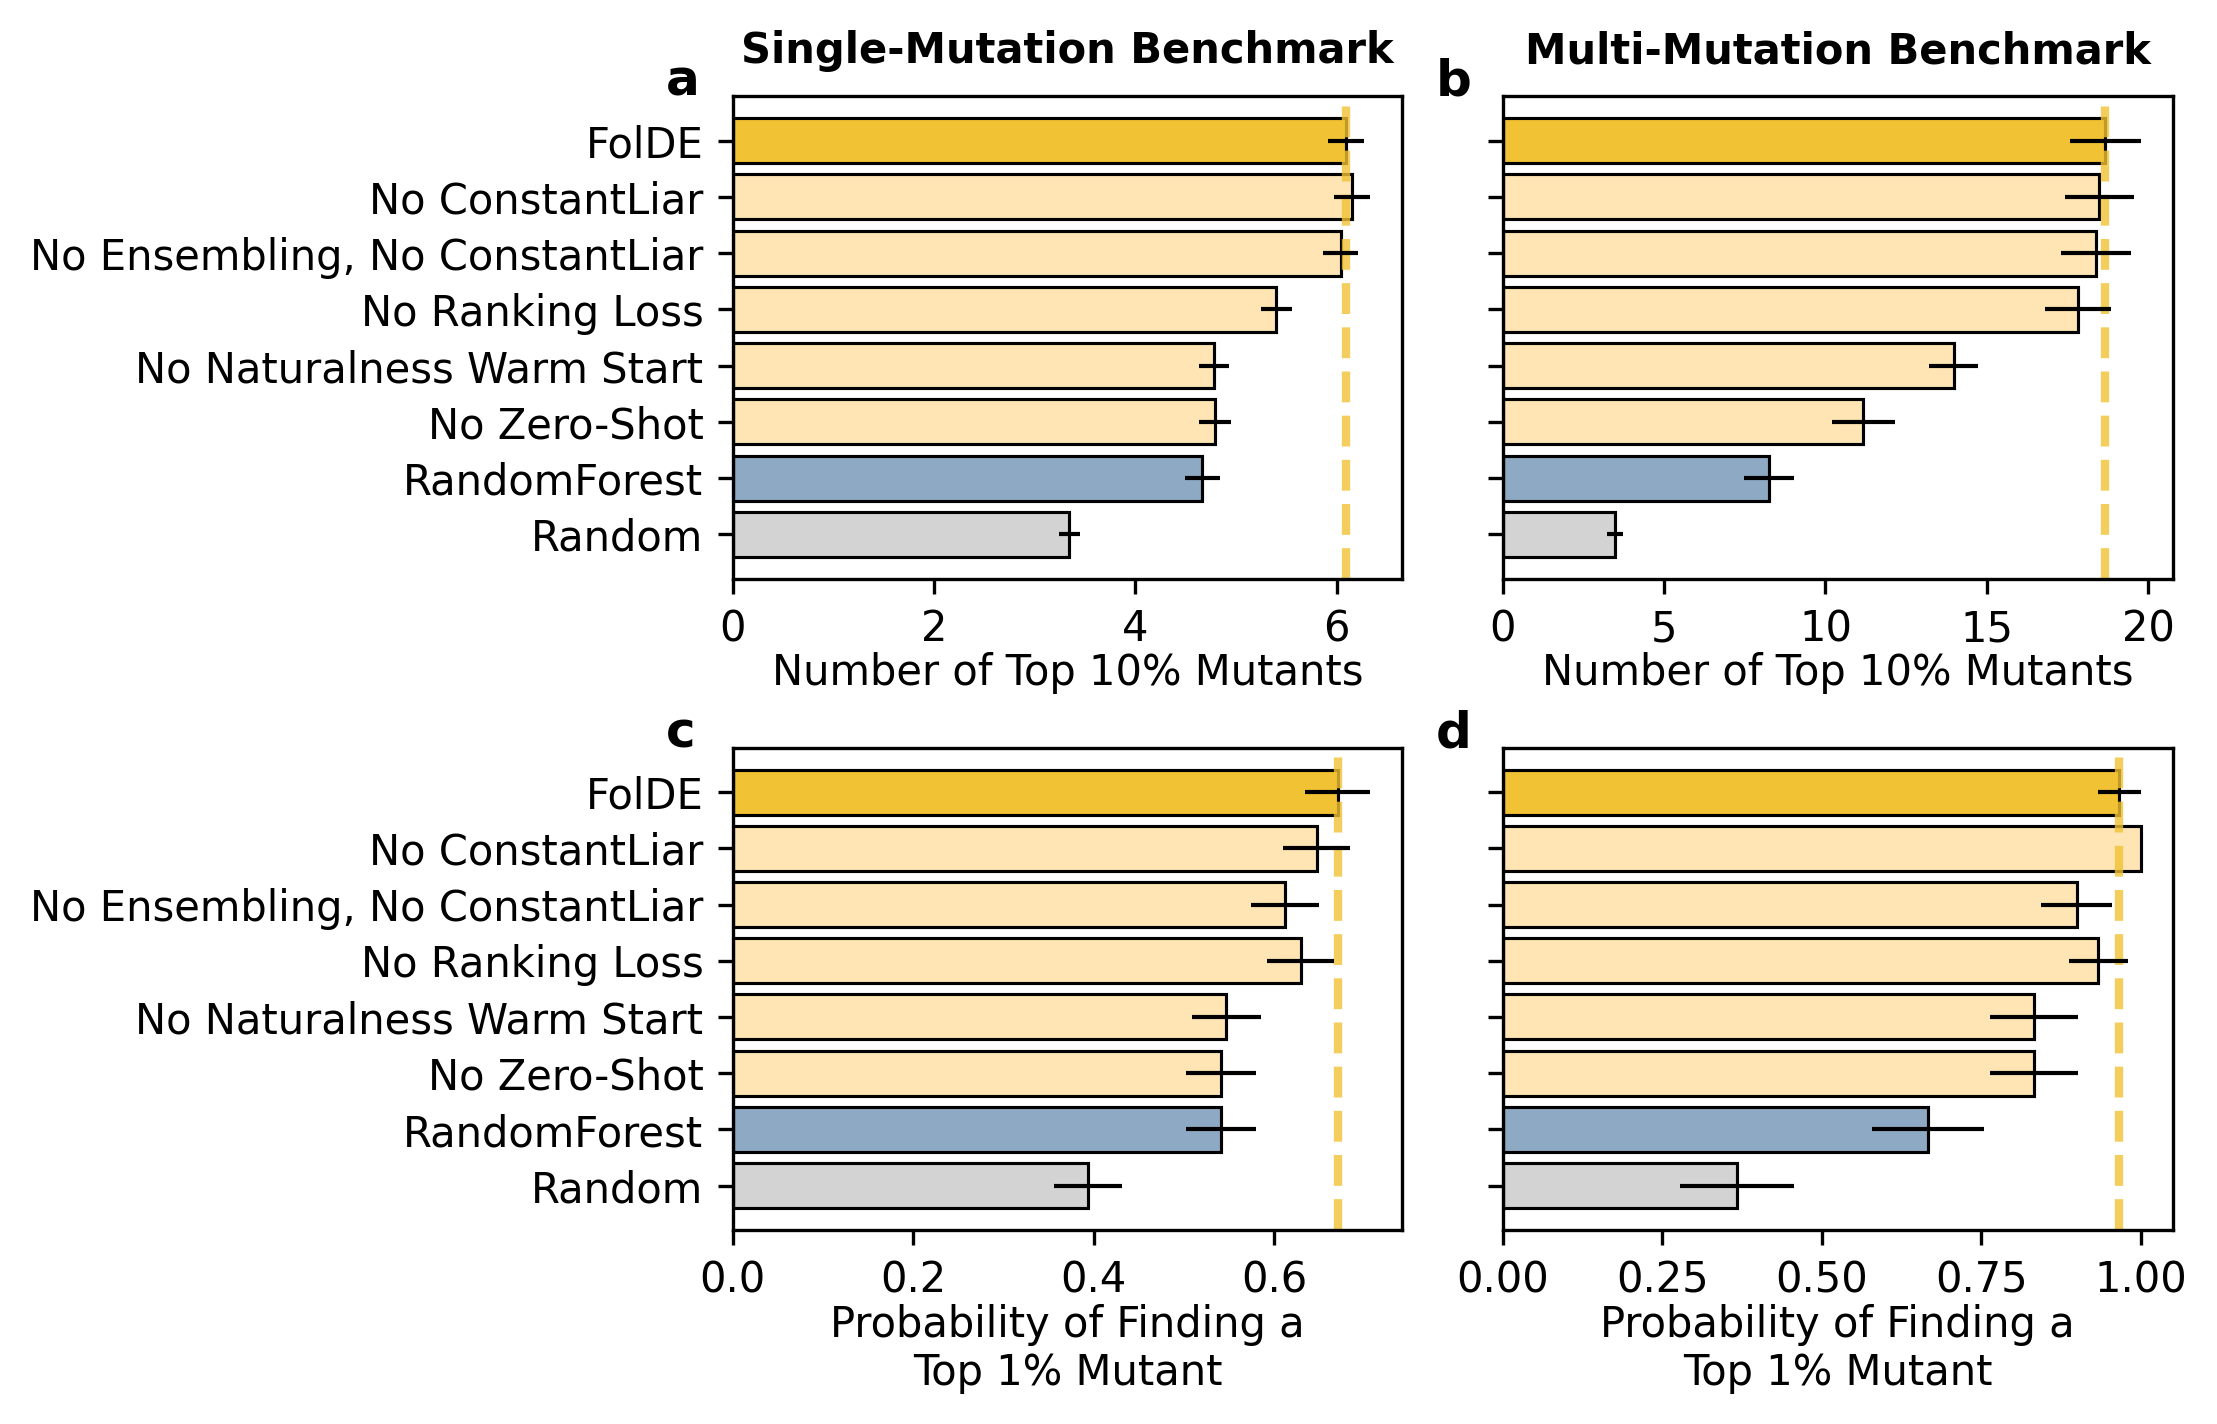

In [20]:
# Improved ablation study plot
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns

N_ROUNDS = 3

configs = [
    ('FolDE-base', 'FolDE'),
    ('FolDE-no-constantliar', 'No ConstantLiar'),
    ('FolDE-no-ensemble', 'No Ensembling, No ConstantLiar'),
    ('FolDE-no-BTLoss', 'No Ranking Loss'),
    ('FolDE-no-naturalnessTraining', 'No Naturalness Warm Start'),
    ('FolDE-no-zeroShot', 'No Zero-Shot'),
    ('RandomToRandomForest-base', 'RandomForest'),
    ('Random', 'Random')
]

def make_ablation_plot(specific_round_metrics_df, ax, metric):
    plot_df = specific_round_metrics_df.copy()
    plot_df['config_name'] = plot_df['config_name'].apply(lambda x: dict(configs).get(x, x))

    if metric == 'has_found_top_1pct':
        subplot_df = plot_df[(plot_df.round_num == 3) & plot_df.config_name.isin([c for _, c in configs])]
    else:
        subplot_df = plot_df[(plot_df.round_num <= 3) & plot_df.config_name.isin([c for _, c in configs])]

    folde_performance = subplot_df[subplot_df.config_name == 'FolDE'][metric].mean()
    config_means = subplot_df.groupby('config_name')[metric].mean()
    config_sems = subplot_df.groupby('config_name')[metric].sem()

    y_positions = [-i for i in range(len(configs))]
    bar_heights = [config_means.get(config[1], 0) for config in configs]
    bar_errors = [config_sems.get(config[1], 0) for config in configs]

    ax.axvline(x=folde_performance, color='#F1C233', linewidth=2, alpha=0.8, linestyle='--')
    
    bars = ax.barh(
        y_positions, bar_heights,
        edgecolor='black', linewidth=0.75,
        color=[{
            'FolDE': '#F1C233',
            'RandomForest': '#8DA9C4',
            'Random': 'lightgrey'
        }.get(config[1], '#FFE5B4') for config in configs],
        xerr=bar_errors, error_kw=dict(ecolor='black', capthick=1, elinewidth=1)
    )

    ax.set_yticks(y_positions)
    ax.set_yticklabels([config[1] for config in configs])

    XLABEL_PARAMS = dict(
        fontsize=10,
        labelpad=0.5  # Add negative labelpad to move label closer to ticks
    )

    if metric == 'cumulative_10pct_hits':
        ax.set_xlabel('Number of Top 10% Mutants', **XLABEL_PARAMS)
    elif metric == 'has_found_top_1pct':
        ax.set_xlabel('Probability of Finding a\nTop 1% Mutant', **XLABEL_PARAMS)
    else:
        ax.set_xlabel(metric)

# Create figure with constrained_layout for better spacing
fig = plt.figure(figsize=(6, 4.5), dpi=300, constrained_layout=False)
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.15, left=0.18, right=0.98, top=0.94, bottom=0.1)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1], sharey=ax_a)
ax_c = fig.add_subplot(gs[1, 0], sharey=ax_a)
ax_d = fig.add_subplot(gs[1, 1], sharey=ax_a)

# Make plots
make_ablation_plot(singles_round_metrics_df, ax_a, 'cumulative_10pct_hits')
make_ablation_plot(multi_round_metrics_df, ax_b, 'cumulative_10pct_hits')
make_ablation_plot(singles_round_metrics_df, ax_c, 'has_found_top_1pct')
make_ablation_plot(multi_round_metrics_df, ax_d, 'has_found_top_1pct')

# Add titles
ax_a.set_title('Single-Mutation Benchmark', fontsize=10, pad=8, fontweight='bold')
ax_b.set_title('Multi-Mutation Benchmark', fontsize=10, pad=8, fontweight='bold')

# Add panel labels (a, b, c, d)
for label, ax in [('a', ax_a), ('b', ax_b), ('c', ax_c), ('d', ax_d)]:
    ax.text(-0.10, 1.08, label, transform=ax.transAxes, fontsize=12, fontweight='bold', va='top')

# Remove y-tick labels from right column
plt.setp(ax_b.get_yticklabels(), visible=False)
plt.setp(ax_d.get_yticklabels(), visible=False)

# Ensure x-labels show on top row
ax_a.tick_params(labelbottom=True)
ax_b.tick_params(labelbottom=True)

fig.savefig('notebooks/jacob/paperplots/fig4_ablation_study.svg', transparent=True, dpi=300, bbox_inches='tight')

<Axes: xlabel='round_num', ylabel='cumulative_1pct_hits'>

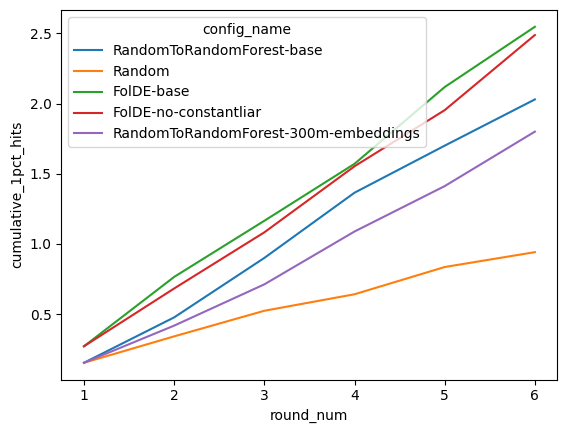

In [6]:

sns.lineplot(
    data=singles_round_metrics_df[singles_round_metrics_df.config_name.isin([
        'FolDE-base',
        'FolDE-no-constantliar',
        'RandomToRandomForest-base',
        'RandomToRandomForest-300m-embeddings',
        'Random',
    ])],
    x='round_num',
    # y='has_found_top_1pct',
    y='cumulative_1pct_hits',
    # y='cumulative_10pct_hits',
    hue='config_name',
    # style='config_name',
    markers=False,
    dashes=False,
    errorbar=None
)

In [7]:
plot_df[(plot_df.round_num <= 2) & (plot_df.config_name.isin([c for _, c in configs]))]

,dms_id,config_name,sim_num,variant_pool_size,best_activity_this_round,best_percentile_this_round,best_activity_so_far,normalized_best_activity_so_far,best_percentile_so_far,round_num,...,held_out_activity_spearman,held_out_1pct_recall,held_out_1pct_recall_slate,held_out_1pct_auc,held_out_10pct_recall,held_out_10pct_recall_slate,held_out_10pct_auc,zero_shot_debug_info,few_shot_debug_info,dms_shortname
0,ANCSZ_Hobbs_2022,Random Zero-Shot,0,2335,0.072834,0.072834,0.072834,0.435350,0.934475,1,...,NaN,0.000000,0.0000,0.466591,0.136752,0.1875,0.528088,{},NaN,ANCSZ
1,ANCSZ_Hobbs_2022,Random Zero-Shot,0,2335,0.148432,0.148432,0.148432,0.476102,0.982013,2,...,NaN,0.083333,0.1250,0.638991,0.188034,0.3750,0.652774,NaN,"{'sorts': {'selection_order': ['R385S', 'D486P...",ANCSZ
0,ANCSZ_Hobbs_2022,Random Zero-Shot,1,2335,0.128522,0.128522,0.128522,0.465369,0.975161,1,...,NaN,0.000000,0.0000,0.528631,0.072650,0.0625,0.487965,{},NaN,ANCSZ
1,ANCSZ_Hobbs_2022,Random Zero-Shot,1,2335,0.040683,0.040683,0.128522,0.465369,0.975161,2,...,NaN,0.125000,0.1250,0.672112,0.166667,0.3125,0.664963,NaN,"{'sorts': {'selection_order': ['M363D', 'F414D...",ANCSZ
0,ANCSZ_Hobbs_2022,Random Zero-Shot,2,2335,0.063062,0.063062,0.063062,0.430082,0.928480,1,...,NaN,0.000000,0.0000,0.454655,0.111111,0.0625,0.500864,{},NaN,ANCSZ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,SHOC2_HUMAN_Kwon_2022,No Ranking Loss,7,5486,0.499495,0.499495,0.499495,0.549560,0.934743,2,...,NaN,0.018182,0.0625,0.614459,0.109290,0.0625,0.521196,NaN,"{'sorts': {'selection_order': ['S215K', 'Y358Q...",SHOC2_HUMAN
0,SHOC2_HUMAN_Kwon_2022,No Ranking Loss,8,5486,0.706788,0.706788,0.706788,0.571865,0.966825,1,...,NaN,0.072727,0.0000,0.743906,0.145719,0.0625,0.618219,{'model_type': 'NaturalnessZeroShotModel'},NaN,SHOC2_HUMAN
1,SHOC2_HUMAN_Kwon_2022,No Ranking Loss,8,5486,0.612262,0.612262,0.706788,0.571865,0.966825,2,...,NaN,0.036364,0.0000,0.652590,0.125683,0.1250,0.529754,NaN,"{'sorts': {'selection_order': ['Y358K', 'S2G',...",SHOC2_HUMAN
0,SHOC2_HUMAN_Kwon_2022,No Ranking Loss,9,5486,0.706788,0.706788,0.706788,0.571865,0.968283,1,...,NaN,0.054545,0.0000,0.701811,0.123862,0.0625,0.618912,{'model_type': 'NaturalnessZeroShotModel'},NaN,SHOC2_HUMAN
